In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files

In [ ]:
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))
print("\nFiles in session:")
for f in sorted(os.listdir()):
    print("-", f)

Saving amazon_echo_show_hpc_20251013_144055.csv to amazon_echo_show_hpc_20251013_144055.csv
Saving continuous_nest_hub_hpc_20251013_121850.csv to continuous_nest_hub_hpc_20251013_121850.csv
Saving lenovo_smart_display_hpc_20251013_120236.csv to lenovo_smart_display_hpc_20251013_120236.csv
Saving real_media_perf_30ms.csv to real_media_perf_30ms.csv
Saving ring_doorbell_hpc_20251014_114513.csv to ring_doorbell_hpc_20251014_114513.csv
Uploaded files: ['amazon_echo_show_hpc_20251013_144055.csv', 'continuous_nest_hub_hpc_20251013_121850.csv', 'lenovo_smart_display_hpc_20251013_120236.csv', 'real_media_perf_30ms.csv', 'ring_doorbell_hpc_20251014_114513.csv']

Files in session:
- .config
- amazon_echo_show_hpc_20251013_144055.csv
- continuous_nest_hub_hpc_20251013_121850.csv
- lenovo_smart_display_hpc_20251013_120236.csv
- real_media_perf_30ms.csv
- ring_doorbell_hpc_20251014_114513.csv
- sample_data


In [ ]:
def parse_perf_stat_interval_csv(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(";")]
            if len(parts) < 4:
                continue
            try:
                t = float(parts[0])
            except ValueError:
                continue
            raw_value = parts[1]
            event = parts[3].split(":")[0]
            if "<not supported>" in raw_value:
                continue
            try:
                value = float(raw_value.replace(",", ""))
            except ValueError:
                continue
            rows.append({"time_sec": t, "event": event, "value": value})

    df = pd.DataFrame(rows)
    wide_df = df.pivot_table(
        index="time_sec",
        columns="event",
        values="value",
        aggfunc="first"
    ).reset_index()
    wide_df.columns.name = None
    return wide_df

def convert_real_perf_to_project_schema(df):
    out = pd.DataFrame()
    out["timestamp"] = df["time_sec"]
    out["hw_cpu_cycles"] = df.get("cycles", 0.0)
    out["hw_instructions_retired"] = df.get("instructions", 0.0)
    out["hw_cache_references"] = df.get("cache-references", 0.0)
    cache_misses = df.get("cache-misses", 0.0)
    out["hw_instructions_per_cycle"] = (
        out["hw_instructions_retired"] / out["hw_cpu_cycles"].replace(0, np.nan)
    ).fillna(0)
    out["hw_cache_miss_rate"] = (
        cache_misses / out["hw_cache_references"].replace(0, np.nan)
    ).fillna(0)
    return out

shared_cols = [
    "hw_cpu_cycles",
    "hw_instructions_retired",
    "hw_instructions_per_cycle",
    "hw_cache_references",
    "hw_cache_miss_rate",
]

ratio_cols = [
    "hw_instructions_per_cycle",
    "hw_cache_miss_rate",
]

def log_mean_cosine(real_df, synth_df, cols):
    real_mean = np.log1p(real_df[cols]).mean().values.reshape(1, -1)
    synth_mean = np.log1p(synth_df[cols]).mean().values.reshape(1, -1)
    return cosine_similarity(real_mean, synth_mean)[0, 0], real_mean, synth_mean

def ratio_cosine(real_df, synth_df, cols):
    real_mean = real_df[cols].mean().values.reshape(1, -1)
    synth_mean = synth_df[cols].mean().values.reshape(1, -1)
    return cosine_similarity(real_mean, synth_mean)[0, 0]

def percent_diff_table(real_df, synth_df, cols, synth_name="synthetic"):
    out = pd.DataFrame({
        "real_mean": real_df[cols].mean(),
        f"{synth_name}_mean": synth_df[cols].mean()
    })
    out["abs_diff"] = (out["real_mean"] - out[f"{synth_name}_mean"]).abs()
    out["percent_diff_vs_real"] = (
        out["abs_diff"] / out["real_mean"].replace(0, np.nan)
    ) * 100
    return out

def make_boxplots(real_df, synth_df, label, cols):
    for col in cols:
        plt.figure(figsize=(7,4))
        plt.boxplot(
            [real_df[col].dropna(), synth_df[col].dropna()],
            labels=[f"Real {col}", f"{label} {col}"]
        )
        plt.title(f"Comparison of {col}: Real vs {label}")
        plt.tight_layout()
        plt.show()

def compare_device(real_clean, synth_df, device_label):
    synth_active = synth_df[synth_df["workload_intensity"] > 10].copy()
    synth_subset = synth_active[shared_cols].copy()
    real_subset = real_clean[shared_cols].copy()

    log_cos, real_mean, synth_mean = log_mean_cosine(real_subset, synth_subset, shared_cols)
    ratio_cos = ratio_cosine(real_clean, synth_active, ratio_cols)

    print(f"=== {device_label} ===")
    print("Cosine similarity (log-mean profile):", round(log_cos, 3))
    print("Cosine similarity (ratios only):", round(ratio_cos, 3))

    profile_df = pd.DataFrame({
        "feature": shared_cols,
        "real_log_mean": real_mean.flatten(),
        f"{device_label}_log_mean": synth_mean.flatten()
    })
    display(profile_df)

    full_compare = percent_diff_table(real_subset, synth_subset, shared_cols, synth_name=device_label.lower().replace(" ", "_"))
    ratio_compare = percent_diff_table(real_clean, synth_active, ratio_cols, synth_name=device_label.lower().replace(" ", "_"))

    print(f"{device_label} full-feature comparison")
    display(full_compare.round(6))

    print(f"{device_label} ratio comparison")
    display(ratio_compare.round(6))

    make_boxplots(real_clean, synth_active, device_label, ratio_cols)

    return {
        "comparison": device_label,
        "log_mean_cosine": log_cos,
        "ratio_cosine": ratio_cos,
        "rows_real": len(real_clean),
        "rows_synth_active": len(synth_active),
    }

In [ ]:
def first_match(substrings):
    files_in_session = os.listdir()
    for sub in substrings:
        matches = [f for f in files_in_session if sub in f and f.endswith(".csv")]
        if matches:
            return matches[0]
    return None

REAL_FILE = first_match(["real_media_perf_30ms"])
device_files = {
    "Amazon Echo Show": first_match(["amazon_echo_show"]),
    "Continuous Nest Hub": first_match(["continuous_nest_hub", "nest_hub"]),
    "Lenovo Smart Display": first_match(["lenovo_smart_display"]),
    "Ring Doorbell": first_match(["ring_doorbell"]),
}

print("REAL_FILE:", REAL_FILE)
print("Detected device files:")
for k, v in device_files.items():
    print("-", k, "=>", v)

assert REAL_FILE is not None, "Could not find real_media_perf_30ms CSV. Upload it first."
available_devices = {k: v for k, v in device_files.items() if v is not None}
assert available_devices, "No media/display device CSVs found. Upload at least one synthetic dataset."

REAL_FILE: real_media_perf_30ms.csv
Detected device files:
- Amazon Echo Show => amazon_echo_show_hpc_20251013_144055.csv
- Continuous Nest Hub => continuous_nest_hub_hpc_20251013_121850.csv
- Lenovo Smart Display => lenovo_smart_display_hpc_20251013_120236.csv
- Ring Doorbell => ring_doorbell_hpc_20251014_114513.csv


In [ ]:
real_media_raw = parse_perf_stat_interval_csv(REAL_FILE)
real_media_clean = convert_real_perf_to_project_schema(real_media_raw)

print("Real media cleaned dataset:")
display(real_media_clean.head())

real_media_clean.to_csv("real_media_cleaned_hpc.csv", index=False)
print("Saved cleaned file as real_media_cleaned_hpc.csv")

Real media cleaned dataset:


,timestamp,hw_cpu_cycles,hw_instructions_retired,hw_cache_references,hw_instructions_per_cycle,hw_cache_miss_rate
0,0.030113,39180436.0,28226987.0,12121146.0,0.720436,0.034426
1,0.064438,4253696.0,2339113.0,1005251.0,0.549901,0.041087
2,0.094608,278264.0,81669.0,23422.0,0.293495,0.181112
3,0.124776,315679.0,107449.0,30228.0,0.340374,0.186615
4,0.154950,268085.0,92635.0,25595.0,0.345543,0.207462


Saved cleaned file as real_media_cleaned_hpc.csv


Loaded Amazon Echo Show from amazon_echo_show_hpc_20251013_144055.csv
=== Amazon Echo Show ===
Cosine similarity (log-mean profile): 0.999
Cosine similarity (ratios only): 1.0


,feature,real_log_mean,Amazon Echo Show_log_mean
0,hw_cpu_cycles,18.469448,14.749320
1,hw_instructions_retired,18.301902,14.639242
2,hw_instructions_per_cycle,0.621811,0.641838
3,hw_cache_references,17.166278,12.380297
4,hw_cache_miss_rate,0.025018,0.052568


Amazon Echo Show full-feature comparison


,real_mean,amazon_echo_show_mean,abs_diff,percent_diff_vs_real
hw_cpu_cycles,1.300772e+08,2.572752e+06,1.275045e+08,98.022136
hw_instructions_retired,1.175697e+08,2.304162e+06,1.152655e+08,98.040173
hw_instructions_per_cycle,8.696330e-01,9.037890e-01,3.415600e-02,3.927582
hw_cache_references,3.707696e+07,2.412643e+05,3.683570e+07,99.349288
hw_cache_miss_rate,2.698500e-02,5.402200e-02,2.703700e-02,100.189399


Amazon Echo Show ratio comparison


,real_mean,amazon_echo_show_mean,abs_diff,percent_diff_vs_real
hw_instructions_per_cycle,0.869633,0.903789,0.034156,3.927582
hw_cache_miss_rate,0.026985,0.054022,0.027037,100.189399


/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


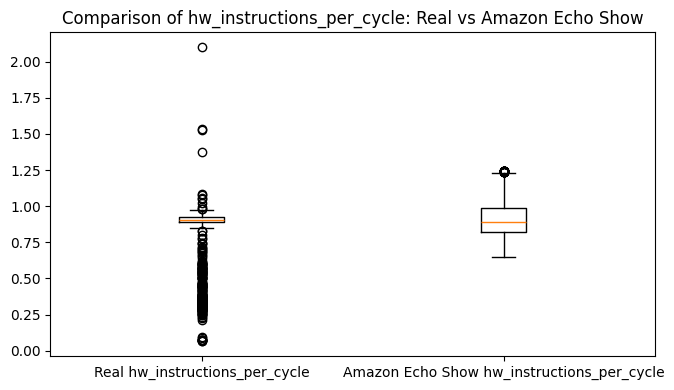

/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


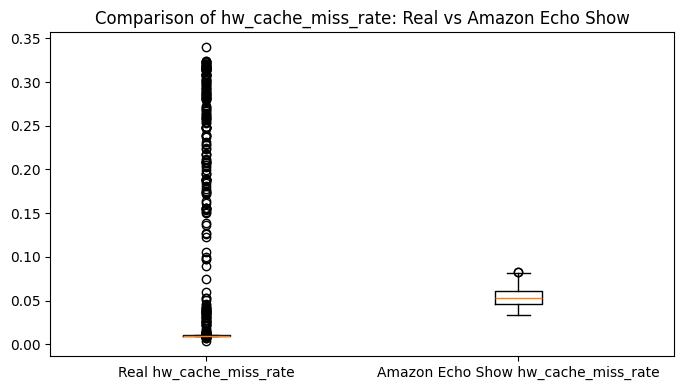

Loaded Continuous Nest Hub from continuous_nest_hub_hpc_20251013_121850.csv
=== Continuous Nest Hub ===
Cosine similarity (log-mean profile): 0.999
Cosine similarity (ratios only): 0.999


,feature,real_log_mean,Continuous Nest Hub_log_mean
0,hw_cpu_cycles,18.469448,14.684094
1,hw_instructions_retired,18.301902,14.575355
2,hw_instructions_per_cycle,0.621811,0.642586
3,hw_cache_references,17.166278,12.316413
4,hw_cache_miss_rate,0.025018,0.058983


Continuous Nest Hub full-feature comparison


,real_mean,continuous_nest_hub_mean,abs_diff,percent_diff_vs_real
hw_cpu_cycles,1.300772e+08,2.394780e+06,1.276825e+08,98.158956
hw_instructions_retired,1.175697e+08,2.147448e+06,1.154222e+08,98.173468
hw_instructions_per_cycle,8.696330e-01,9.054060e-01,3.577200e-02,4.113476
hw_cache_references,3.707696e+07,2.248484e+05,3.685211e+07,99.393563
hw_cache_miss_rate,2.698500e-02,6.082100e-02,3.383600e-02,125.384335


Continuous Nest Hub ratio comparison


,real_mean,continuous_nest_hub_mean,abs_diff,percent_diff_vs_real
hw_instructions_per_cycle,0.869633,0.905406,0.035772,4.113476
hw_cache_miss_rate,0.026985,0.060821,0.033836,125.384335


/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


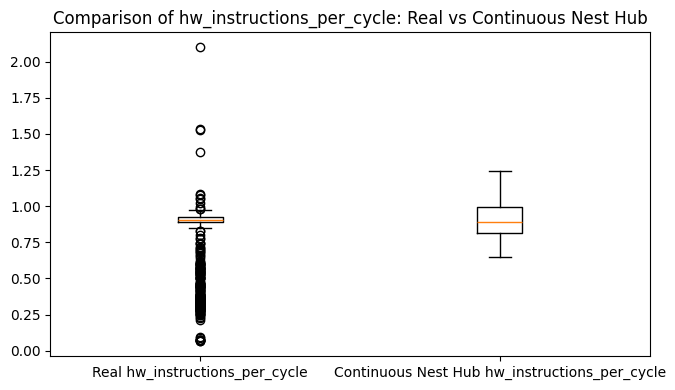

/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


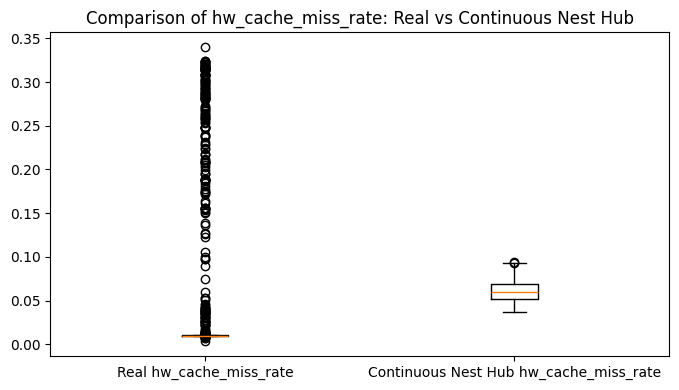

Loaded Lenovo Smart Display from lenovo_smart_display_hpc_20251013_120236.csv
=== Lenovo Smart Display ===
Cosine similarity (log-mean profile): 0.999
Cosine similarity (ratios only): 0.999


,feature,real_log_mean,Lenovo Smart Display_log_mean
0,hw_cpu_cycles,18.469448,14.784286
1,hw_instructions_retired,18.301902,14.641266
2,hw_instructions_per_cycle,0.621811,0.626737
3,hw_cache_references,17.166278,12.421711
4,hw_cache_miss_rate,0.025018,0.059053


Lenovo Smart Display full-feature comparison


,real_mean,lenovo_smart_display_mean,abs_diff,percent_diff_vs_real
hw_cpu_cycles,1.300772e+08,2.647542e+06,1.274297e+08,97.964639
hw_instructions_retired,1.175697e+08,2.295351e+06,1.152743e+08,98.047668
hw_instructions_per_cycle,8.696330e-01,8.756660e-01,6.032000e-03,0.693683
hw_cache_references,3.707696e+07,2.498186e+05,3.682714e+07,99.326216
hw_cache_miss_rate,2.698500e-02,6.089800e-02,3.391200e-02,125.668567


Lenovo Smart Display ratio comparison


,real_mean,lenovo_smart_display_mean,abs_diff,percent_diff_vs_real
hw_instructions_per_cycle,0.869633,0.875666,0.006032,0.693683
hw_cache_miss_rate,0.026985,0.060898,0.033912,125.668567


/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


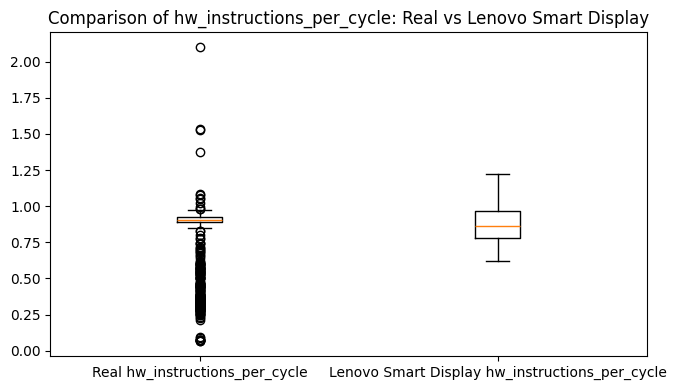

/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


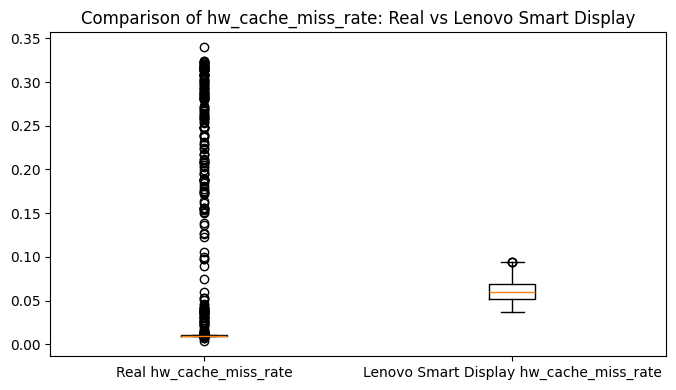

Loaded Ring Doorbell from ring_doorbell_hpc_20251014_114513.csv
=== Ring Doorbell ===
Cosine similarity (log-mean profile): 0.999
Cosine similarity (ratios only): 1.0


,feature,real_log_mean,Ring Doorbell_log_mean
0,hw_cpu_cycles,18.469448,14.790633
1,hw_instructions_retired,18.301902,14.667902
2,hw_instructions_per_cycle,0.621811,0.635853
3,hw_cache_references,17.166278,12.413184
4,hw_cache_miss_rate,0.025018,0.051841


Ring Doorbell full-feature comparison


,real_mean,ring_doorbell_mean,abs_diff,percent_diff_vs_real
hw_cpu_cycles,1.300772e+08,2.703054e+06,1.273742e+08,97.921962
hw_instructions_retired,1.175697e+08,2.390065e+06,1.151796e+08,97.967108
hw_instructions_per_cycle,8.696330e-01,8.923440e-01,2.271000e-02,2.611491
hw_cache_references,3.707696e+07,2.513647e+05,3.682560e+07,99.322046
hw_cache_miss_rate,2.698500e-02,5.325300e-02,2.626700e-02,97.337730


Ring Doorbell ratio comparison


,real_mean,ring_doorbell_mean,abs_diff,percent_diff_vs_real
hw_instructions_per_cycle,0.869633,0.892344,0.022710,2.611491
hw_cache_miss_rate,0.026985,0.053253,0.026267,97.337730


/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


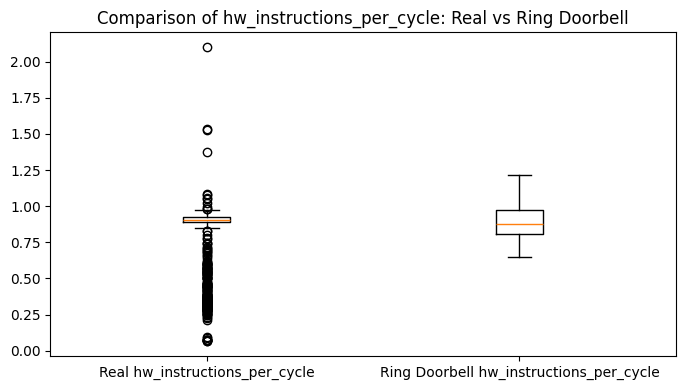

/tmp/ipykernel_8263/1178612195.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


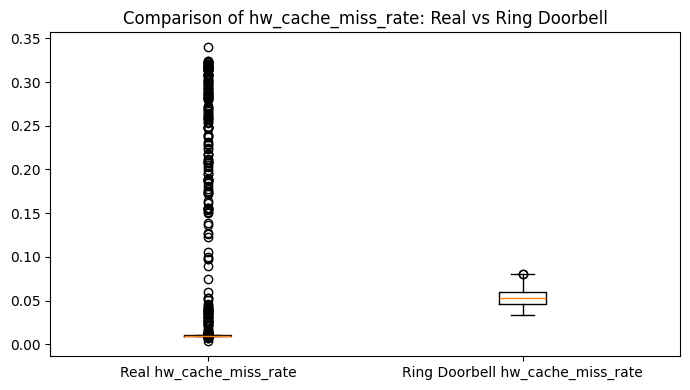

In [ ]:
results = []
loaded_devices = {}

for device_label, file_name in available_devices.items():
    synth_df = pd.read_csv(file_name)
    loaded_devices[device_label] = synth_df
    print(f"Loaded {device_label} from {file_name}")
    results.append(compare_device(real_media_clean, synth_df, device_label))

In [ ]:
summary = pd.DataFrame(results)
display(summary.round(6))

,comparison,log_mean_cosine,ratio_cosine,rows_real,rows_synth_active
0,Amazon Echo Show,0.998910,0.999589,2163,20000
1,Continuous Nest Hub,0.998892,0.999350,2163,11649
2,Lenovo Smart Display,0.998955,0.999262,2163,20000
3,Ring Doorbell,0.998917,0.999591,2163,9473


In [ ]:
device_names = list(loaded_devices.keys())
mat = pd.DataFrame(index=device_names, columns=device_names, dtype=float)

for d1 in device_names:
    for d2 in device_names:
        a = loaded_devices[d1][loaded_devices[d1]["workload_intensity"] > 10][ratio_cols].mean().values.reshape(1, -1)
        b = loaded_devices[d2][loaded_devices[d2]["workload_intensity"] > 10][ratio_cols].mean().values.reshape(1, -1)
        mat.loc[d1, d2] = cosine_similarity(a, b)[0, 0]

display(mat.round(6))

,Amazon Echo Show,Continuous Nest Hub,Lenovo Smart Display,Ring Doorbell
Amazon Echo Show,1.000000,0.999973,0.999953,1.000000
Continuous Nest Hub,0.999973,1.000000,0.999997,0.999972
Lenovo Smart Display,0.999953,0.999997,1.000000,0.999952
Ring Doorbell,1.000000,0.999972,0.999952,1.000000
